# Market Signal Analysis

This notebook performs a simple market time-series analysis using sample price data.

The goal is to demonstrate basic data loading, timestamp cleaning, feature engineering, and visual inspection of price and volatility.


In [31]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sys

sys.path.append(str(Path.cwd().parent / "src"))

from metrics import (
    calculate_returns,
    calculate_max_drawdown,
    calculate_win_rate,
    calculate_sharpe_like,
)
from signals import momentum_signal

data_path = Path("../data/sample_prices.csv")

df = pd.read_csv(data_path)

df.head()

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")
df = df.set_index("timestamp")

df.head()

df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2024-01-01 00:00:00 to 2024-01-02 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes


## Feature engineering


In [32]:
rolling_window = 24

df["return"] = calculate_returns(df["close"])
df["rolling_mean"] = df["close"].rolling(window=rolling_window).mean()
df["rolling_volatility"] = df["return"].rolling(window=rolling_window).std()

df.head(30)

,close,return,rolling_mean,rolling_volatility
timestamp,,,,
2024-01-01 00:00:00,42100.5,NaN,NaN,NaN
2024-01-01 01:00:00,42210.2,0.002606,NaN,NaN
2024-01-01 02:00:00,42080.7,-0.003068,NaN,NaN
2024-01-01 03:00:00,42350.1,0.006402,NaN,NaN
2024-01-01 04:00:00,42420.3,0.001658,NaN,NaN
2024-01-01 05:00:00,42310.8,-0.002581,NaN,NaN
2024-01-01 06:00:00,42540.6,0.005431,NaN,NaN
2024-01-01 07:00:00,42620.4,0.001876,NaN,NaN
2024-01-01 08:00:00,42490.2,-0.003055,NaN,NaN


# Price chart


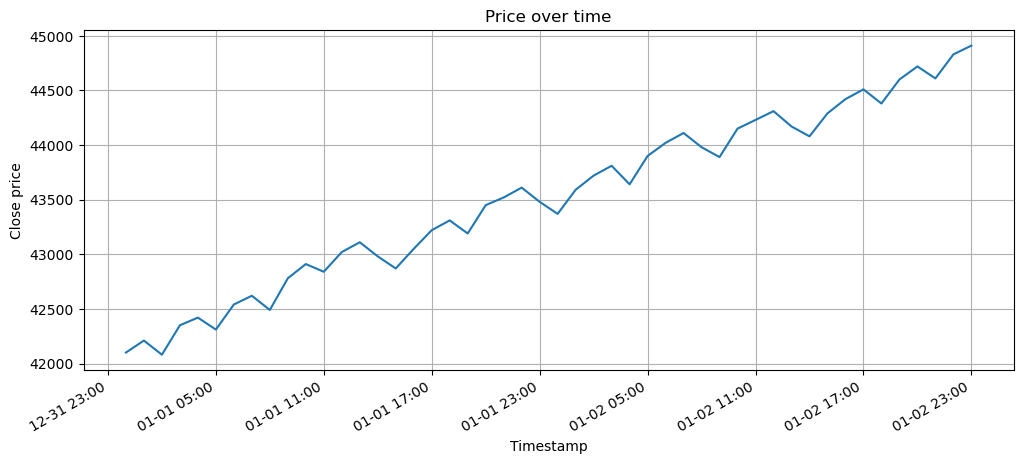

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["close"], linewidth=1.5)

ax.set_title("Price over time")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Close price")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


# Rolling volatility chart

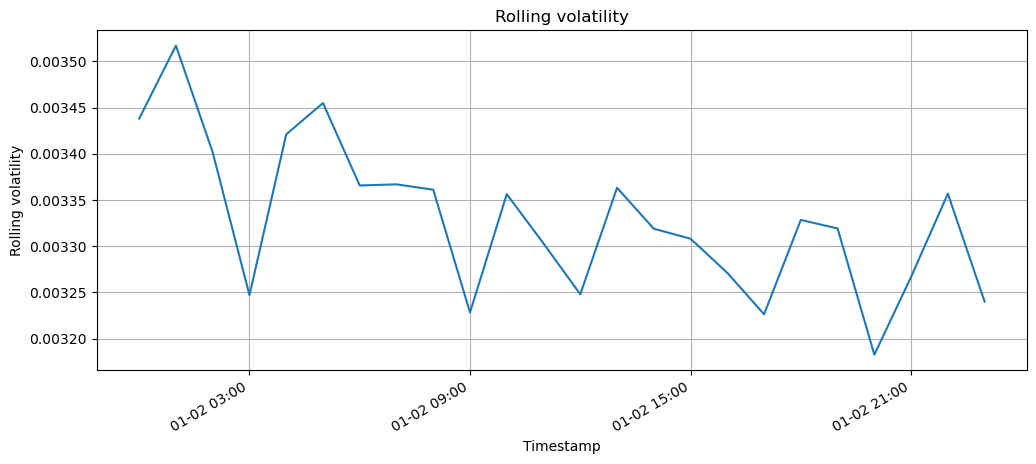

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["rolling_volatility"], linewidth=1.5)

ax.set_title("Rolling volatility")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Rolling volatility")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Initial observations

The dataset is sorted by timestamp and indexed as a time series.  
The return column measures percentage price changes between consecutive observations.  
Rolling volatility is calculated as the rolling standard deviation of returns.

At this stage, the notebook only performs basic exploratory analysis. No trading signal or backtest is included yet.


## Momentum signal

A simple momentum signal is based on recent returns.  
If the rolling return is positive, the signal is long. If it is negative, the signal is short.


In [35]:
signal_window = 12

df["momentum_signal"] = momentum_signal(df["return"], window=signal_window)

df[["return", "momentum_signal"]].tail()


,return,momentum_signal
timestamp,,
2024-01-02 19:00:00,0.004953,1
2024-01-02 20:00:00,0.002682,1
2024-01-02 21:00:00,-0.002449,1
2024-01-02 22:00:00,0.004927,1
2024-01-02 23:00:00,0.001793,1


## Backtest setup

The signal is shifted by one period before calculating strategy returns.  
This avoids using information from the current bar to trade the same bar.


In [36]:
df["position"] = df["momentum_signal"].shift(1)

df[["momentum_signal", "position"]].tail()


,momentum_signal,position
timestamp,,
2024-01-02 19:00:00,1,1.0
2024-01-02 20:00:00,1,1.0
2024-01-02 21:00:00,1,1.0
2024-01-02 22:00:00,1,1.0
2024-01-02 23:00:00,1,1.0


## Strategy returns

Strategy returns are calculated by multiplying the shifted position by the market return.


In [37]:
df["strategy_return"] = df["position"] * df["return"]
df["equity_curve"] = (1 + df["strategy_return"].fillna(0)).cumprod()

df[["return", "position", "strategy_return", "equity_curve"]].tail()


,return,position,strategy_return,equity_curve
timestamp,,,,
2024-01-02 19:00:00,0.004953,1.0,0.004953,1.036724
2024-01-02 20:00:00,0.002682,1.0,0.002682,1.039504
2024-01-02 21:00:00,-0.002449,1.0,-0.002449,1.036959
2024-01-02 22:00:00,0.004927,1.0,0.004927,1.042068
2024-01-02 23:00:00,0.001793,1.0,0.001793,1.043937


## Backtest metrics

The metrics summarize the simplified momentum backtest.


In [38]:
metrics = {
    "cumulative_return": df["equity_curve"].iloc[-1] - 1,
    "max_drawdown": calculate_max_drawdown(df["equity_curve"]),
    "win_rate": calculate_win_rate(df["strategy_return"]),
    "sharpe_like": calculate_sharpe_like(
        df["strategy_return"],
        periods_per_year=24 * 365,
    ),
}

metrics


{'cumulative_return': 0.043937090603107354,
 'max_drawdown': -0.0055694217636579335,
 'win_rate': 0.48936170212765956,
 'sharpe_like': 30.622628487199695}

## Equity curve


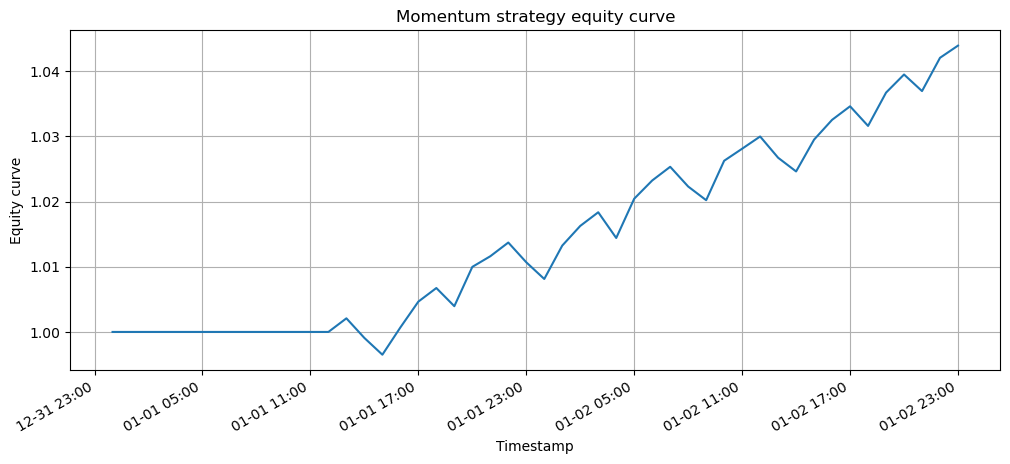

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["equity_curve"], linewidth=1.5)

ax.set_title("Momentum strategy equity curve")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Equity curve")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Backtest interpretation

The momentum signal produces a positive cumulative return on this sample dataset.

This result should be interpreted carefully. The dataset is small and trends upward, which makes a momentum signal look better than it would on a broader market sample.

The backtest also uses simplified execution assumptions and does not include transaction costs, slippage, liquidity constraints, or out-of-sample validation.


## Drawdown


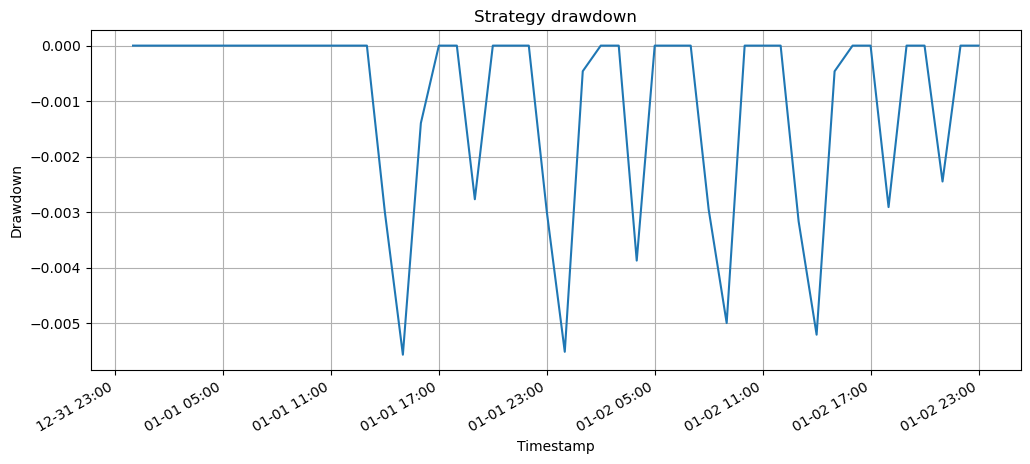

In [40]:
running_max = df["equity_curve"].cummax()
df["drawdown"] = df["equity_curve"] / running_max - 1

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["drawdown"], linewidth=1.5)

ax.set_title("Strategy drawdown")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Drawdown")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Position


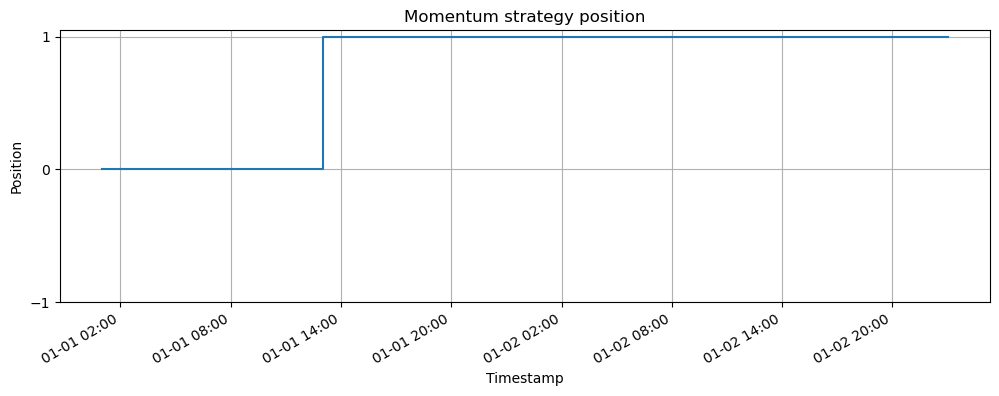

In [41]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.step(df.index, df["position"], where="post")

ax.set_title("Momentum strategy position")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Position")
ax.set_yticks([-1, 0, 1])
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


### Interpretation

The position chart shows that the strategy is mostly long on this sample, which reflects the upward trend in the dataset and limits how much can be concluded from the result.
